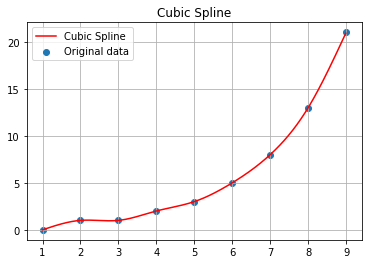

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


#get the second derivatives
def getM(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n-2)
    B = np.zeros(n-2)
    C = np.zeros(n-2)
    D = np.zeros(n-2)

    for i in range(1, n-1):
        A[i-1] = h[i-1]
        B[i-1] = 2*(h[i-1] + h[i])
        C[i-1] = h[i]
        D[i-1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])

    M_inner = thomas_algorithm(A, B, C, D)
    M = np.concatenate(([0], M_inner, [0])) 

    return M


# the spline at 1x 
def spline_eval(x, y, M, xval):
    i = np.searchsorted(x, xval) - 1
    i = np.clip(i, 0, len(x)-2)

    h = x[i+1] - x[i]

    term1 = (M[i]/(6*h)) * (x[i+1]-xval)**3
    term2 = (M[i+1]/(6*h)) * (xval-x[i])**3
    term3 = (y[i]/h - (M[i]*h)/6) * (x[i+1]-xval)
    term4 = (y[i+1]/h - (M[i+1]*h)/6) * (xval-x[i])

    return term1 + term2 + term3 + term4


x = np.array([1,2,3,4,5,6,7,8,9])
y = np.array([0,1,1,2,3,5,8,13,21])

# using hint on slack
x = np.sort(x) 

M = getM(x, y)

# iteration
x_plot = np.arange(x[0], x[-1], 0.01)
y_plot = np.zeros(len(x_plot))

for i in range(len(x_plot)):
    y_plot[i] = spline_eval(x, y, M, x_plot[i])

# plot
plt.scatter(x, y, label="Original data")
plt.plot(x_plot, y_plot, label="Cubic Spline", color='red')
plt.legend()
plt.grid()
plt.title("Cubic Spline")
plt.show()